In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [15]:
df = pd.read_csv("Loan_default.csv")
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [19]:
df.fillna({
 'Income': df['Income'].median(),
 'CreditScore': df['CreditScore'].median(),
 'LoanAmount': df['LoanAmount'].median(),
 'Age': df['Age'].median()
}, inplace=True)

label = LabelEncoder()
df['MaritalStatus'] = label.fit_transform(df['MaritalStatus'])
df['Education'] = label.fit_transform(df['Education'])

features = ['Income','CreditScore','LoanAmount','LoanTerm','Age']
X = df[features]
y = df['Default']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

Decision Tree Accuracy: 0.7949872723712551
[[39526  5644]
 [ 4826  1074]]
              precision    recall  f1-score   support

           0       0.89      0.88      0.88     45170
           1       0.16      0.18      0.17      5900

    accuracy                           0.79     51070
   macro avg       0.53      0.53      0.53     51070
weighted avg       0.81      0.79      0.80     51070

Random Forest Accuracy: 0.8834345016643822
[[44875   295]
 [ 5658   242]]
              precision    recall  f1-score   support

           0       0.89      0.99      0.94     45170
           1       0.45      0.04      0.08      5900

    accuracy                           0.88     51070
   macro avg       0.67      0.52      0.51     51070
weighted avg       0.84      0.88      0.84     51070



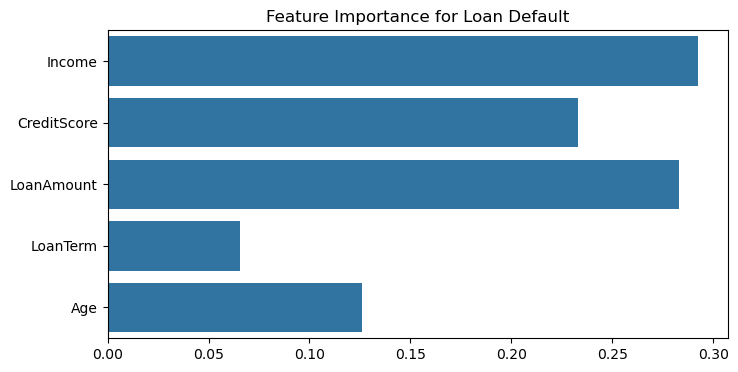

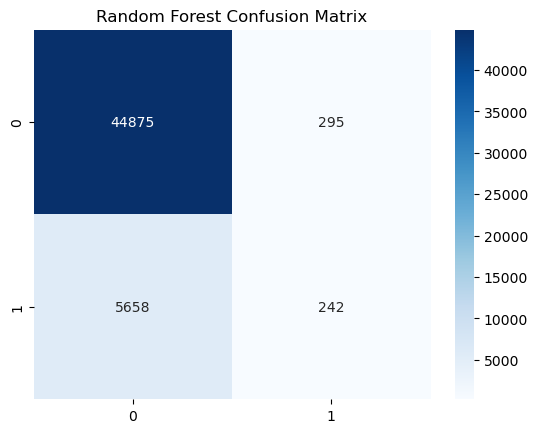

In [25]:
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print(confusion_matrix(y_test, dt_pred))
print(classification_report(y_test, dt_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

importances = rf.feature_importances_
plt.figure(figsize=(8,4))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance for Loan Default")
plt.show()

sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt="d",
cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.show()